<a href="https://colab.research.google.com/github/rlarudals016esaa/assignment/blob/main/ESAA_YB_WEEK11_assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/code/subinium/subinium-tutorial-house-prices-advanced

1. 위 캐글을 필사 - 새롭게 공부한 내용(개념, 코드)을 함께 정리해두기를 추천합니다

2. 수상작을 선정해 리뷰한 후, 정리한 사이트(노션, 블로그 등)의 링크를 댓글로 달아주세요.

#House Prices



### 라이브러리, 데이터 확인하기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import norm, skew
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# sns Theme
sns.set_style('darkgrid')

#소수점 표현 제한
pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

#디렉토리 내, 사용가능 파일 체크
#from subprocess import check_output
#print(check_output(['ls', '../input']).decode('utf-8'))

In [3]:
 #구글드라이브 마운트
 from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_df = pd.read_csv('/content/drive/MyDrive/data/House/train.csv')
test_df = pd.read_csv('/content/drive/MyDrive/data/House/test.csv')

In [5]:
print(train_df.shape, test_df.shape)
train_df.head(5)

(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
#Save the 'Id' column
train_ID = train_df['Id']
test_ID = test_df['Id']

#drop the 'Id' column since it's unnecessary for the Prediction process
train_df.drop('Id', axis=1, inplace=True)
test_df.drop('Id', axis=1, inplace=True)

### 데이터 전처리

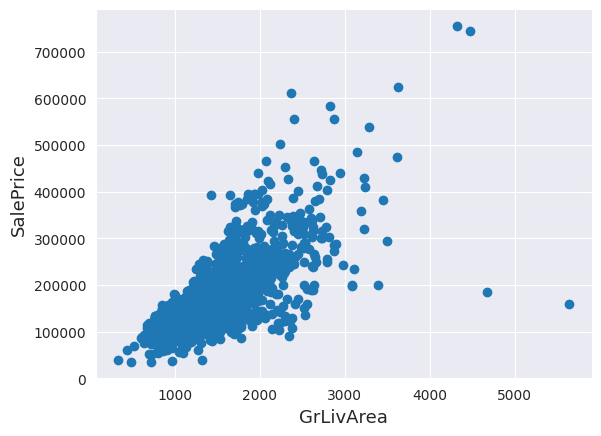

In [7]:
fig, ax = plt.subplots()

ax.scatter(x=train_df['GrLivArea'], y=train_df['SalePrice'])
plt.ylabel('SalePrice', fontsize=13)
plt.xlabel('GrLivArea', fontsize=13)
plt.show()

이상치 제거는 훈련에 있어 매우 좋은 방법이나, 이상치를 일일히 제거하지 않는 이유는 테스트 데이터에도 이상치가 있을 수 있기 때문이다.

- Target Variable
SalePrice는 예측해야 하는 타겟값이다.

180921.19589041095 79415.29188606751


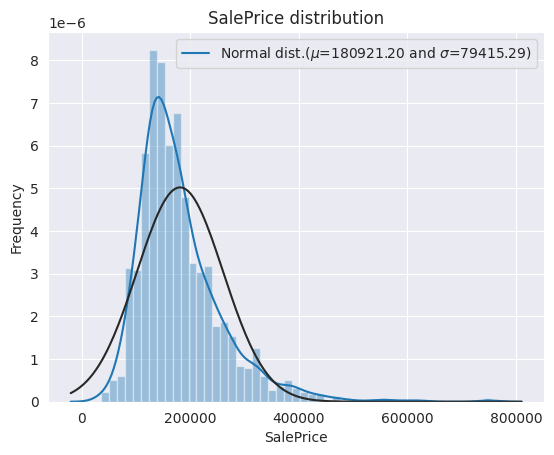

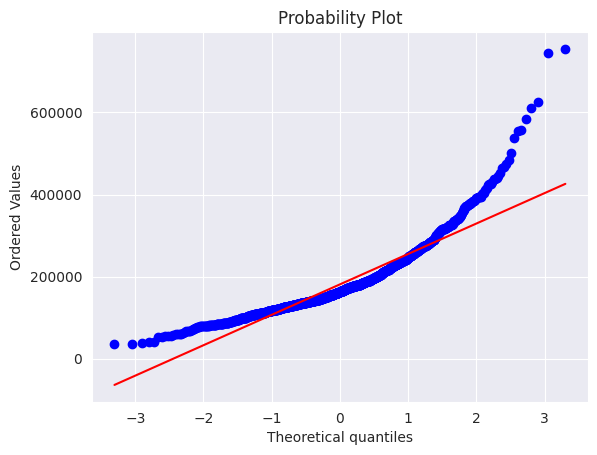

In [8]:
sns.distplot(train_df['SalePrice'], fit=norm)

#Get the fitted parameters used by the function
(mu, sigma) = norm.fit(train_df['SalePrice'])
print(mu, sigma)

#분포를 그래프에 그린다.
plt.legend(['Normal dist.($\mu$={:.2f} and $\sigma$={:.2f})'.format(mu,sigma)], loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

fig = plt.figure()
res = stats.probplot(train_df['SalePrice'], plot=plt)
plt.show()

분포가 오른쪽으로 치우친 것을 알 수 있다. 일반적으로 선형 모델은 분포가 균형잡힌 상태에 더 용이하여 데이터 전처리가 더 필요하다.

$$log(1+x)함수 사용$$

12.024057394918406 0.39931245219387496


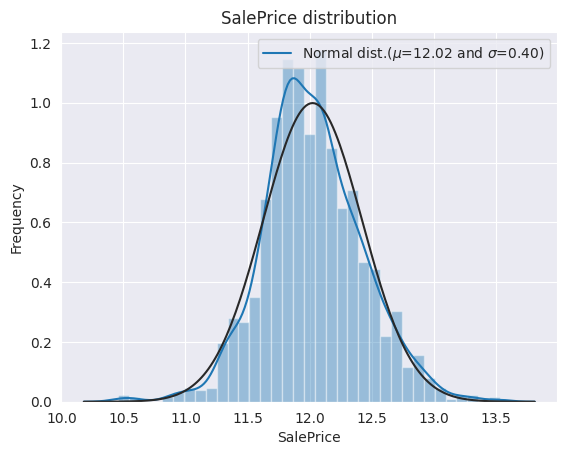

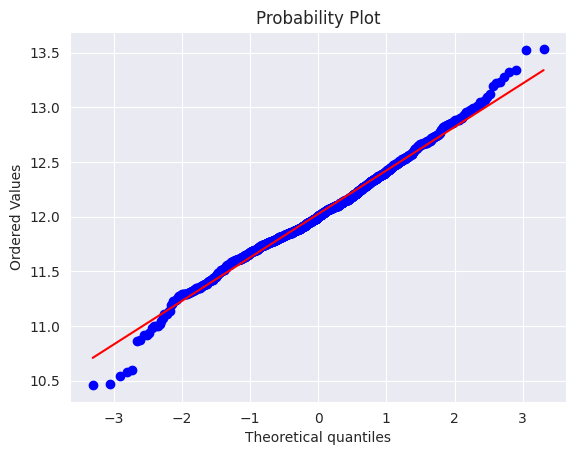

In [9]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

#위에서와 같은 코드로 똑같이 분포를 확인하자
sns.distplot(train_df['SalePrice'], fit=norm)
(mu, sigma) = norm.fit(train_df['SalePrice'])
print(mu, sigma)
plt.legend(['Normal dist.($\mu$={:.2f} and $\sigma$={:.2f})'.format(mu,sigma)], loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')
fig = plt.figure()
res = stats.probplot(train_df['SalePrice'],plot=plt)
plt.show()

### 피처 엔지니어링

In [10]:
ntrain = train_df.shape[0]
ntest = test_df.shape[0]

y_train = train_df.SalePrice.values

all_data = pd.concat((train_df, test_df)).reset_index(drop=True)
all_data.drop(['SalePrice'], axis=1, inplace=True)
print("all_data size is : {}".format(all_data.shape))

all_data size is : (2919, 79)


- 전체 데이터에서 빈 부분을 확인

In [11]:
all_data_na = (all_data.isnull().sum()/len(all_data))*100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)[:30]

missing_data = pd.DataFrame({'Missing Ratio': all_data_na})
missing_data.head(20)

,Missing Ratio
PoolQC,99.657
MiscFeature,96.403
Alley,93.217
Fence,80.439
MasVnrType,60.500
FireplaceQu,48.647
LotFrontage,16.650
GarageQual,5.447
GarageYrBlt,5.447
GarageCond,5.447


Text(0.5, 1.0, 'Percent missing data by feature')

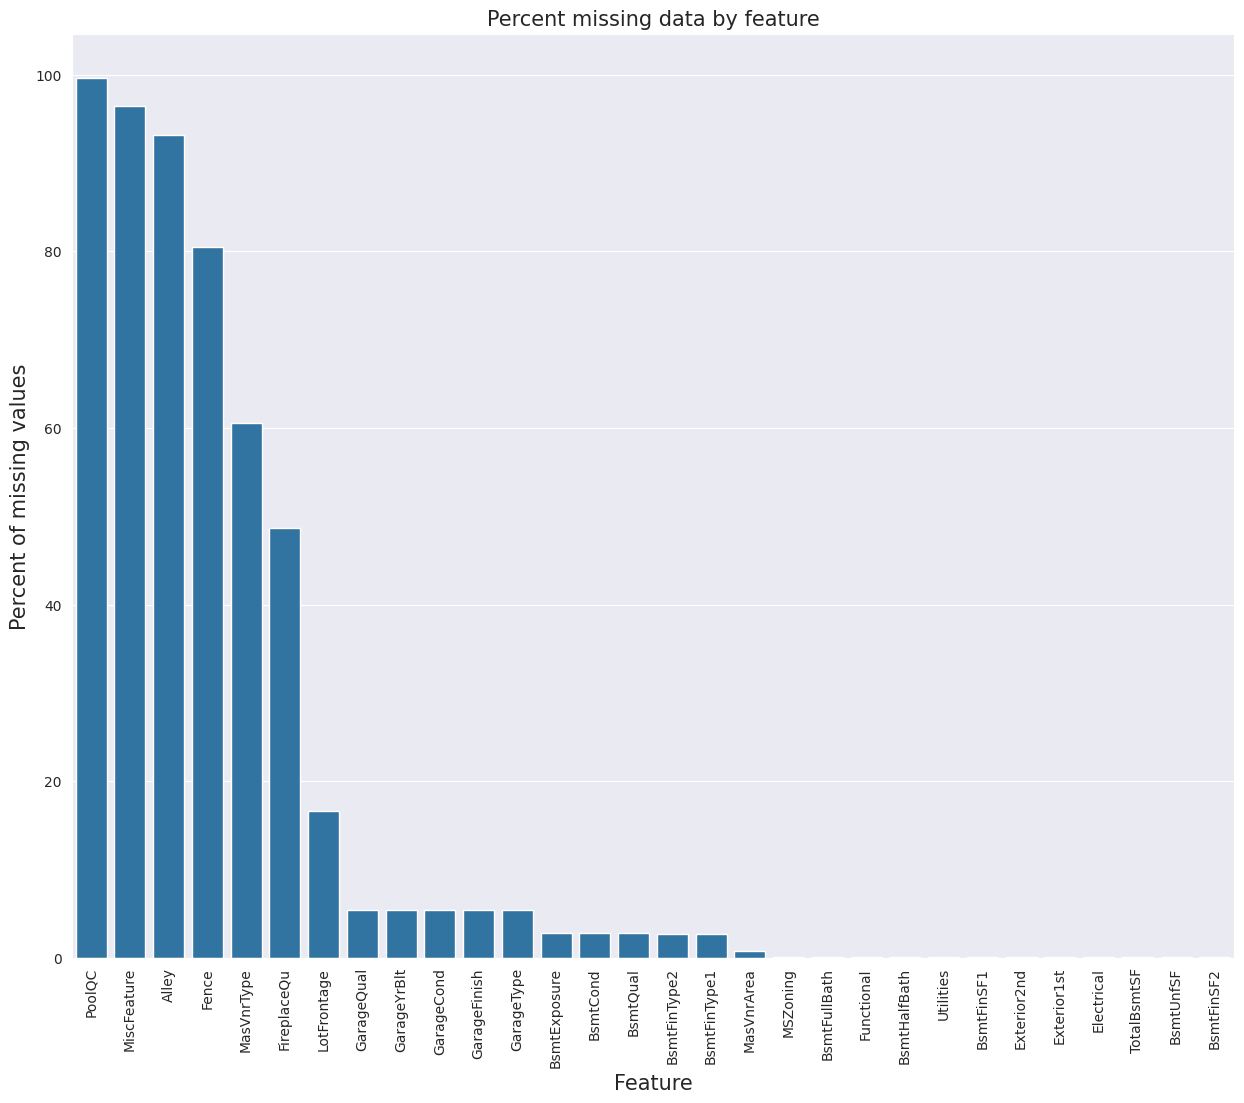

In [12]:
f, ax = plt.subplots(figsize=(15,12))
plt.xticks(rotation='vertical')
sns.barplot(x=all_data_na.index, y=all_data_na)
plt.xlabel('Feature', fontsize=15)
plt.ylabel('Percent of missing values', fontsize=15)
plt.title('Percent missing data by feature', fontsize=15)

- 데이터 상관성

<Axes: >

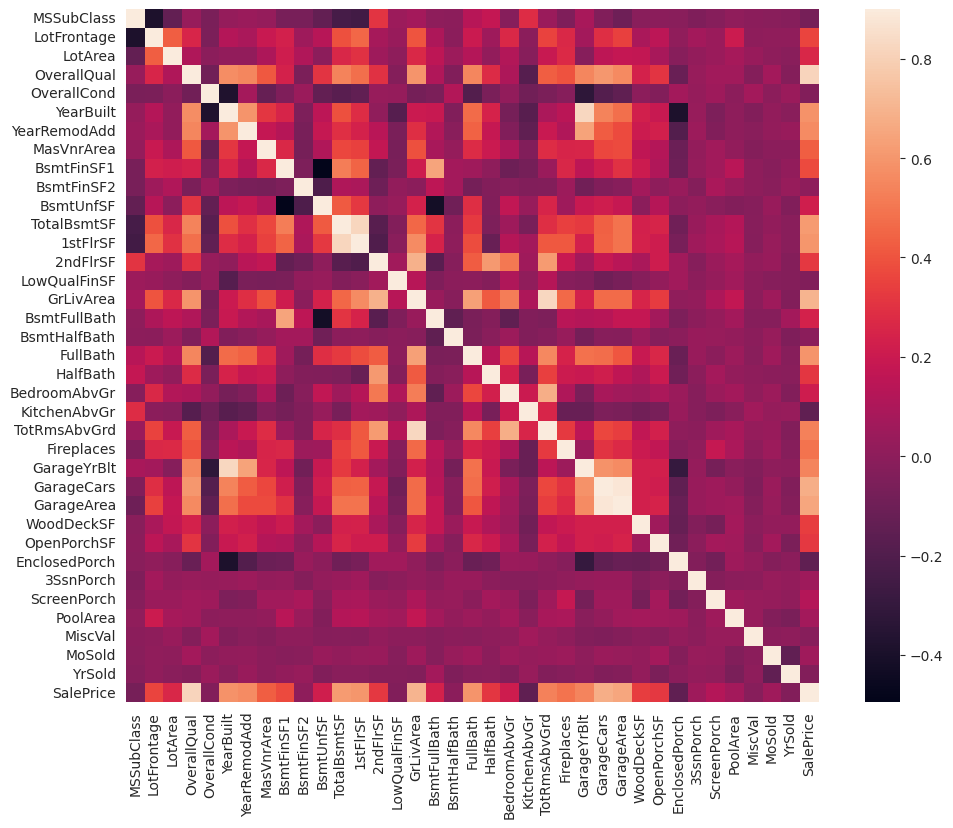

In [13]:
corrmat = train_df.select_dtypes(include=np.number).corr()
plt.subplots(figsize=(12,9))
sns.heatmap(corrmat, vmax=0.9, square=True)

- 누락된 값 채워넣기

PoolQC: NA값은 No Pool을 의미한다.

In [14]:
all_data['PoolQC'] = all_data['PoolQC'].fillna('None')

MisFeature: NA는 nomisc feature이다

In [15]:
all_data["MiscFeature"] = all_data["MiscFeature"].fillna("None")
all_data["Alley"] = all_data["Alley"].fillna("None")
all_data["Fence"] = all_data["Fence"].fillna("None")
all_data["FireplaceQu"] = all_data["FireplaceQu"].fillna("None")

LotFrontage: 거리와 집의 거리 요소로 이웃들의 거리아 유사한 값을 가짐. 손실된 값을 이웃들의 중앙값으로 채움

In [16]:
all_data['LotFrontage'] = all_data.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

GarageType, GarageFinich, GarageQual and GarageCond: 부분도 None처리

In [17]:
for col in ('GarageType', 'GarageFinish','GarageQual', 'GarageCond'):
  all_data[col] = all_data[col].fillna('None')

In [18]:
for col in('GarageYrBlt', 'GarageArea', 'GarageCars'):
  all_data[col] = all_data[col].fillna(0)

In [19]:
for col in ('BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath'):
    all_data[col] = all_data[col].fillna(0)

In [20]:
for col in ('BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'):
    all_data[col] = all_data[col].fillna('None')

In [21]:
all_data["MasVnrType"] = all_data["MasVnrType"].fillna("None")
all_data["MasVnrArea"] = all_data["MasVnrArea"].fillna(0)

- MSZoning: RL이 최빈값으로 빈 부분은 RL로 채운다. mode 메서드는 가장 많이 나타나는 값을 자동으로 선택한다.

In [22]:
all_data['MSZoning'] = all_data['MSZoning'].fillna(all_data['MSZoning'].mode()[0])

- Utilities: 이 데이터는 모든 값이 'AllPub'으로 되어 있고, 한개가 'NoSeWa'그리고 2개의 NA값이 있다.

In [23]:
all_data = all_data.drop(['Utilities'], axis=1)

- Functional: 디스크립션에 의하면 NA는 typical을 의미한다.

In [24]:
all_data['Functional'] = all_data['Functional'].fillna('Typ')

- Electrical, KitchenQual, Exterior1st and Exterior2nd, SaleType:이 데이터 모두 최빈값으로 채운다

In [25]:
all_data['Electrical'] = all_data['Electrical'].fillna(all_data['Electrical'].mode()[0])

In [26]:
all_data['KitchenQual'] = all_data['KitchenQual'].fillna(all_data['KitchenQual'].mode()[0])

In [27]:
all_data['Exterior1st'] = all_data['Exterior1st'].fillna(all_data['Exterior1st'].mode()[0])
all_data['Exterior2nd'] = all_data['Exterior2nd'].fillna(all_data['Exterior2nd'].mode()[0])

In [28]:
all_data['SaleType'] = all_data['SaleType'].fillna(all_data['SaleType'].mode()[0])

In [29]:
all_data['MSSubClass'] = all_data['MSSubClass'].fillna('None')

In [30]:
# check remaining missing values if any
all_data_na = (all_data.isnull().sum()/len(all_data))*100
all_data_na = all_data_na.drop(all_data_na[all_data_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio': all_data_na})
missing_data.head()

,Missing Ratio


- More features engineering


수치형 값들 중 범주형인 특성들을 변환한다

In [31]:
#MSSubClass = The building class
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)

#Changing OverallCond into a categorical variable
all_data['OverallCond'] = all_data['OverallCond'].apply(str)

#Year and Month sold are transformed into categorical features.
all_data['Yrsold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)

범주형 데이터를 label encoding으로 변환한다.

In [32]:
from sklearn.preprocessing import LabelEncoder
cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1',
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond',
        'YrSold', 'MoSold')
# process columns, apply LabelEncoder to categorical features
for c in cols:
    lbl = LabelEncoder()
    lbl.fit(list(all_data[c].values))
    all_data[c] = lbl.transform(list(all_data[c].values))

# shape
print('Shape all_data: {}'.format(all_data.shape))

Shape all_data: (2919, 79)


주택 가격에서 중요한 요소 중 하나는 집의 가용 평수이다.


따라서 이런 특성은 basement+1층+2층 공간으로 새로운 특성을 하나 만든다.

In [33]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['1stFlrSF'] + all_data['2ndFlrSF']

Skewed feature

In [34]:
numeric_feats = all_data.dtypes[all_data.dtypes!='object'].index

#수치형 데이터에서 skewness 체크
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

print('\nSkew in numerical features:\n')
skewness = pd.DataFrame({'Skew': skewed_feats})
skewness.head(10)


Skew in numerical features:



,Skew
MiscVal,21.947
PoolArea,16.898
LotArea,12.822
LowQualFinSF,12.089
3SsnPorch,11.376
LandSlope,4.975
KitchenAbvGr,4.302
BsmtFinSF2,4.146
EnclosedPorch,4.004
ScreenPorch,3.947


Box Cox Trandsformation of (highly) skewed features

In [35]:
skewness = skewness[abs(skewness) >0.75]
print('There are {} skewed numerical features to Box Cox transform'.format(skewness.shape[0]))

from scipy.special import boxcox1p
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
  all_data[feat] = boxcox1p(all_data[feat], lam)

There are 59 skewed numerical features to Box Cox transform


범주형 데이터를 get_dummies를 이용하여 변환한다. 그리고 다시 train_df와 test_df로 나눈다.

In [36]:
all_data = pd.get_dummies(all_data)
print(all_data.shape)
train_df = all_data[:ntrain]
test_df = all_data[ntrain:]

(2919, 226)


### Modeling
모델들의 라이브러리를 import한다.

In [37]:
from sklearn.linear_model import ElasticNet, Lasso, BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import lightgbm as lgb

이 커널에서는 cross_val_score함수를 사용한다. 하지만 이 함수는 순서를 섞지 않기 때문에 검증의 정도를 높이기 위해 K-fold를 사용하여 검증의 정확도를 더 높인다.

In [38]:
# Validation Function
n_folds = 5

def rmsle_cv(model):
  kf = KFold(n_folds, shuffle=True, random_state=42).get_n_splits(train_df.values)
  rmse = np.sqrt(-cross_val_score(model, train_df.values, y_train, scoring='neg_mean_squared_error', cv=kf))
  return(rmse)

### Base Model

- Lasso 회귀 모델은 이상치에 매우 민감하다.

이 이상치를 규제하기 위해 pipeline에 robustscaler()메서드를 이용

- Elastic Net회귀 모델 또한 이상치를 위한 똑같이 진행

In [39]:
lasso = make_pipeline(RobustScaler(), Lasso(alpha=0.0005, random_state=1))
ENet = make_pipeline(RobustScaler(), ElasticNet(alpha=0.0005, l1_ratio=.9, random_state=3))

- Kernel Ridge Regression

In [40]:
KRR = KernelRidge(alpha=0.6, kernel='polynomial', degree=2, coef0=2.5)

- Gradient Boosting Regression

In [41]:
GBoost = GradientBoostingRegressor(n_estimators=3000, learning_rate=0.05, max_depth=4,
                                   max_features='sqrt', min_samples_leaf=15, min_samples_split=10,
                                   loss='huber', random_state=5)

- XGBoost

: 각 매개변수, 즉 하이퍼 파라미터 설정은 bayesian optimization을 사용했다고 함.

In [42]:
model_xgb = xgb.XGBRegressor(colsample_bytree = 0.4603, gamma=0.0468,
                             learning_rate = 0.05, max_depth=3,
                             min_child_weight=1.7817, n_estimators=2200,
                             reg_alpha=0.4640, reg_lambda=0.8571,
                             subsample=0.5213, silent=1,
                             random_state=7, nthread=-1)

- LightGBM

In [43]:
model_lgb = lgb.LGBMRegressor(objective='regression', num_leaves=5,
                              learning_rate=0.05, n_estimators=720,
                              max_bin=55, bagging_fraction=0.8,
                              bagging_freq=5, feature_fraction=0.2319,
                              feature_fraction_seed=9, bagging_seed=9,
                              min_data_in_leaf=6, min_sum_hessian_in_leaf=11)

- Base models scores

교차검증을 통해 score를 구한다

In [44]:
score = rmsle_cv(lasso)
print('\nLasso score: {:.4f}, ({:.4f})\n'.format(score.mean(), score.std()))


Lasso score: 0.1240, (0.0166)



In [45]:
score = rmsle_cv(ENet)
print('ElasticNet score: {:.4f}, ({:.4f})\n'.format(score.mean(), score.std()))

ElasticNet score: 0.1240, (0.0166)



In [46]:
score = rmsle_cv(KRR)
print('Kernel Ridge score: {:.4f}, ({:.4f})\n'.format(score.mean(), score.std()))

Kernel Ridge score: 0.1263, (0.0128)



In [47]:
score = rmsle_cv(GBoost)
print('Gradient Boosting score: {:.4f}, ({:.4f})\n'.format(score.mean(), score.std()))

Gradient Boosting score: 0.1236, (0.0127)



In [48]:
score = rmsle_cv(model_xgb)
print('Xgboost score: {:.4f}, ({:.4f})\n'.format(score.mean(), score.std()))

Xgboost score: 0.1238, (0.0119)



In [49]:
score = rmsle_cv(model_lgb)
print('LGBM score: {:.4f}, ({:.4f})\n'.format(score.mean(), score.std()))

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319

### Stacking models

: 모델들의 성능을 평균하여 사용하는 것으로 시작하고 class를 만들어 캡슐화하고 코드를 재사용할 수 있게 만든다.

In [56]:
class AveragingModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, models):
        self.models = models

    # we define clones of the original models to fit the data in
    def fit(self, X, y):
        self.models_ = [clone(x) for x in self.models]

        # Train cloned base models
        for model in self.models_:
            model.fit(X, y)

        return self

    #Now we do the predictions for cloned models and average them
    def predict(self, X):
        predictions = np.column_stack([
            model.predict(X) for model in self.models_
        ])
        return np.mean(predictions, axis=1)

Averaged base models score

[ENet, GBoost, KRR, Lasso]

In [57]:
averaged_models = AveragingModels(models = (ENet, GBoost, KRR, lasso))

score = rmsle_cv(averaged_models)
print("Averaged base models score: {:.4f} ({:.4f})\n".format(score.mean(), score.std()))

Averaged base models score: 0.1195 (0.0147)



### Less simple Stacking: Adding a Meta-model

1. 훈련 데이터를 분리된 데이터셋 train, holdout으로 나눈다.
2. train 데이터로 훈련을 한다.
3. holdout데이터로 테스트를 한다.
4. 3)을 통해 예측값을 구하고 , meta model을 통해 그 예측 값으로 모델을 학습한다.

첫 세 단계는 순서대로 진행한다. 만약 5-fold stacking을 한다면, 5-folds를 예시로 들어보자

그렇다면, 훈련 데이터를 5개로 나누고, 총 5번의 반복문을 진행한다. 각 반복문은 4folds로 훈련을 진행하고, 나머지 1fold를 예측한다.

5번의 반복문이 끄타면 모든 데이터는 out-of-folds예측값을 가지게 되고, 이제 이 값들을 이용해 meta model의 입력으로 사용한다.

예측 부분에 있어 테스트 데이터에서 모든 모델의 예측값을 평균내고, 이를 meta-features로 사용하여 meta-model로 마지막 예측값을 만든다.

### Stacking averaged Models Class

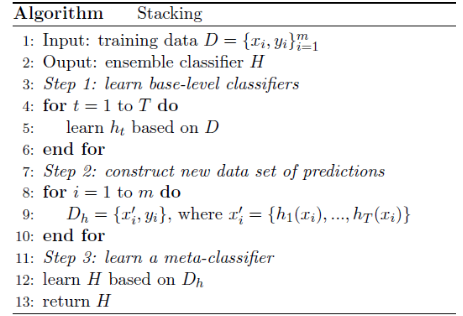

In [58]:
class StackingAveragedModels(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, base_models, meta_model, n_folds=5):
        self.base_models = base_models
        self.meta_model = meta_model
        self.n_folds = n_folds

    # base_models_는 2차원 배열입니다.
    def fit(self, X, y):
        self.base_models_ = [list() for x in self.base_models]
        self.meta_model_ = clone(self.meta_model)
        kfold = KFold(n_splits=self.n_folds, shuffle=True, random_state=156)

        # Train cloned base models then create out-of-fold predictions
        # that are needed to train the cloned meta-model
        out_of_fold_predictions = np.zeros((X.shape[0], len(self.base_models)))
        for i, model in enumerate(self.base_models):
            for train_index, holdout_index in kfold.split(X, y):
                instance = clone(model)
                self.base_models_[i].append(instance)
                instance.fit(X[train_index], y[train_index])
                y_pred = instance.predict(X[holdout_index])
                out_of_fold_predictions[holdout_index, i] = y_pred

        # Now train the cloned  meta-model using the out-of-fold predictions as new feature
        self.meta_model_.fit(out_of_fold_predictions, y)
        return self

    # 각 모델들의 평균값을 사용합니다.
    def predict(self, X):
        meta_features = np.column_stack([
            np.column_stack([model.predict(X) for model in base_models]).mean(axis=1)
            for base_models in self.base_models_ ])
        return self.meta_model_.predict(meta_features)

### Stacking Averaged models Score

In [59]:
stacked_averaged_models = StackingAveragedModels(
    base_models=(ENet, GBoost, KRR),
    meta_model=(lasso)
)

score = rmsle_cv(stacked_averaged_models)
print("Stacking Averaged models score: {:.4f} ({:.4f})".format(score.mean(), score.std()))

Stacking Averaged models score: 0.1195 (0.0142)


### Emsembling StackedRegressor, XGBoost and LightGBM

In [60]:
def rmsle(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

- Final training and prediction

In [61]:
stacked_averaged_models.fit(train_df.values, y_train)
stacked_train_pred = stacked_averaged_models.predict(train_df.values)
stacked_pred = np.expm1(stacked_averaged_models.predict(test_df.values))
print(rmsle(y_train, stacked_train_pred))

0.080826395050144


- XGBoost

In [63]:
model_xgb.fit(train_df, y_train)
xgb_train_pred = model_xgb.predict(train_df)
xgb_pred = np.expm1(model_xgb.predict(test_df))
print(rmsle(y_train, xgb_train_pred))

0.08656546850859813


- LightGBM

In [64]:
model_lgb.fit(train_df, y_train)
lgb_train_pred = model_lgb.predict(train_df)
lgb_pred = np.expm1(model_lgb.predict(test_df))
print(rmsle(y_train, lgb_train_pred))

[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.23

In [65]:
'''RMSE on the entire Train data when averaging'''

print('RMSLE score on train data:')
print(rmsle(y_train,stacked_train_pred*0.70 +
               xgb_train_pred*0.15 + lgb_train_pred*0.15 ))

RMSLE score on train data:
0.07817793282853974


Ensemble prediction

In [66]:
ensemble = stacked_pred*0.70 + xgb_pred*0.15+lgb_pred*0.15

Submission

In [67]:
sub = pd.DataFrame()
sub['Id'] = test_ID
sub['SalePrice'] = ensemble
sub.to_csv('submission.csv',index=False)